# FIT5217: Natural Language Processing Assignment 1


## DU1: Data Understanding

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
# load data from FIT5217_Assignment1_Files folder
test_classification_indexed = pd.read_csv('FIT5217_Assignment1_Files/test_classification_indexed.csv')
test_ngram_indexed = pd.read_csv('FIT5217_Assignment1_Files/test_ngram_indexed.csv')
train_indexed = pd.read_csv('FIT5217_Assignment1_Files/train_indexed.csv')
validation_indexed = pd.read_csv('FIT5217_Assignment1_Files/validation_indexed.csv')

In [32]:
# explore the training corpus
train_indexed.head(10)

,RowId,TextIndexed,Category
0,tr1,"3 4 5 6 7 5 8 9 10, 11 12 13, 14 7 15? 16 17 1...",Type_4
1,tr2,10 32 18 32 33 4 24 34 12 10 35 4 19 36. 37 38...,Type_4
2,tr3,49 50 51 4 52 36 16 53 54 55 51 4 52 36. 56 57...,Type_4
3,tr4,112 113 11 114! 105 115 116 117 118 119 120 12...,Type_4
4,tr5,25 162 21 114 4 163 164 18 33 24 165 162 4 19 ...,Type_4
5,tr6,193! 18 33 24 25 27. 19 194 195 196 197 198 67...,Type_4
6,tr7,19 203 204 37 36 10 16 41 205 4 24 206 67 145 ...,Type_4
7,tr8,254 52 8 151 10 157 215 255 206 67 254 52 8 15...,Type_4
8,tr9,"5 36 204 270 10! 271 272 273, 274 275 24 223 2...",Type_4
9,tr10,10 280 79 281. 153 282 46 283 284 19 36 51 285...,Type_4


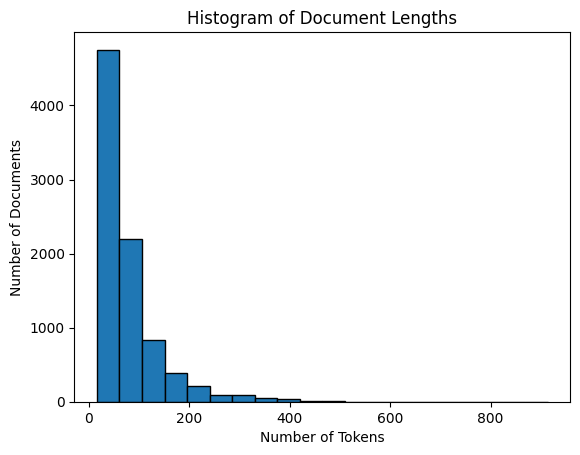

In [33]:
# a histogram of document lengths (tokens per document), 

# count the number of indexed tokens per document
train_indexed['Document_Length'] = train_indexed['TextIndexed'].apply(lambda x: len(x.split()))

# plot the histogram of document lengths
plt.xlabel('Number of Tokens')
plt.ylabel('Number of Documents')
plt.title('Histogram of Document Lengths')
plt.hist(train_indexed['Document_Length'], bins=20, edgecolor='black')
plt.show()


- Most documents have a token length less than 200
- Data sparsity might be an issue for higher order n-grams if the document length is too short; a lower probability that the document contains the specific n-gram


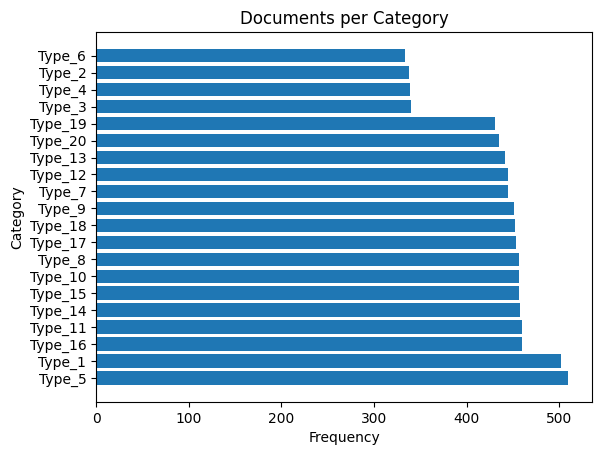

In [34]:
# a bar chart of document counts per category. 

# count the number of documents per category
category_counts = train_indexed['Category'].value_counts()

# plot the bar chart
plt.barh(category_counts.index, category_counts.values)
plt.title("Documents per Category")
plt.xlabel("Frequency")
plt.ylabel("Category")
plt.show()



- Category Types are generally balanced
- An imbalanced dataset would cause majority bias, where the n-gram predicts a certain type only because of its sheer frequency


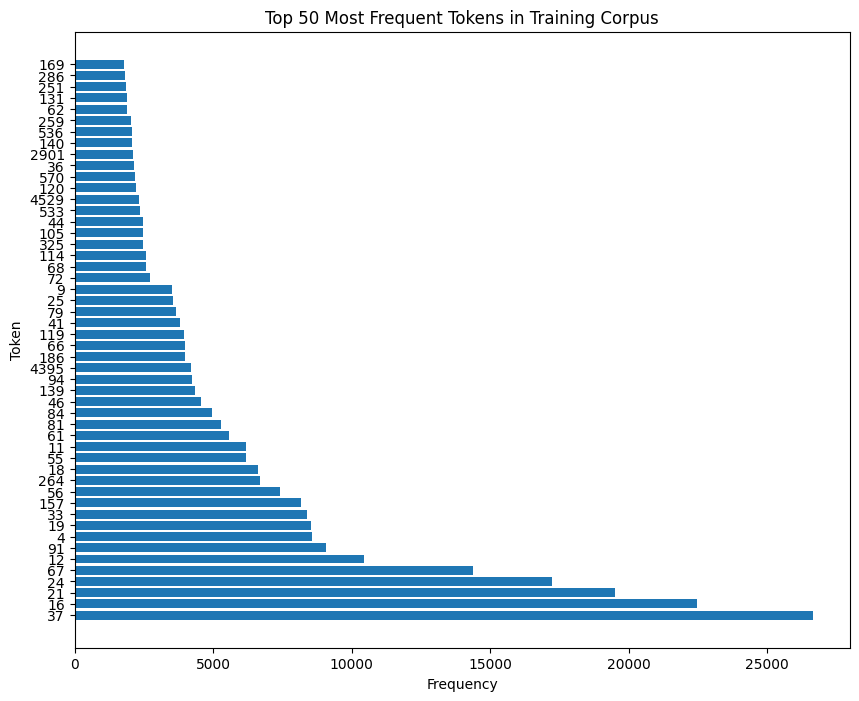

Average token frequency: 5805.0
Maximum token frequency: 26639
Minimum token frequency: 1797
Standard deviation of token frequencies: 5416.942809371352


In [35]:
# bar chart of the top 50 most frequent tokens in the training corpus and the 
# create a list of all tokens in the training corpus
all_tokens = []
for text in train_indexed['TextIndexed']:
    all_tokens.extend(text.split())
# count the frequency of each token
from collections import Counter
token_counts = Counter(all_tokens)
# get the top 50 most frequent tokens
top_50_tokens = token_counts.most_common(50)
# separate the tokens and their counts for plotting
tokens, counts = zip(*top_50_tokens)
# plot the bar chart of the top 50 most frequent tokens
plt.figure(figsize=(10, 8))
plt.barh(tokens[:50], counts[:50])
plt.title("Top 50 Most Frequent Tokens in Training Corpus")
plt.xlabel("Frequency")
plt.ylabel("Token")
#plt.gca().invert_yaxis()  # invert y-axis to show the most frequent token at the top
plt.show()

# get token frequency statistics
avg_frequency = sum(counts) / len(counts)
print(f"Average token frequency: {avg_frequency}")
max_frequency = max(counts)
print(f"Maximum token frequency: {max_frequency}")  
min_frequency = min(counts)
print(f"Minimum token frequency: {min_frequency}")
std_deviation = (sum((x - avg_frequency) ** 2 for x in counts) / len(counts)) ** 0.5
print(f"Standard deviation of token frequencies: {std_deviation}")





## DU2: Stopword Identification

In [36]:
# Calculating Term Frequency 
token_df = pd.DataFrame(token_counts.items(), columns=['Token', 'Frequency'])
token_df['Term_Frequency'] = token_df['Frequency'] / token_df['Frequency'].sum()
token_df.head()


,Token,Frequency,Term_Frequency
0,3,377,0.000567
1,4,8555,0.012875
2,5,978,0.001472
3,6,1232,0.001854
4,7,20,0.000030


In [37]:
# Calculating Document Frequency
document_freq = {}
for text in train_indexed['TextIndexed']:
    # get unique tokens in the document to count document frequency
    unique_tokens = set(text.split())
    for token in unique_tokens:
        # increment the document frequency count for the token
        if token not in document_freq:
            document_freq[token] = 1
        else:
            document_freq[token] += 1

# add document frequency to the token dataframe
token_df['Unique_Documents'] = token_df['Token'].apply(lambda x: document_freq.get(x, 0)) # stores raw document frequency counts
token_df['Document_Frequency'] = token_df['Unique_Documents'] / len(train_indexed) # stores document frequency as a proportion of total documents
token_df.head()

,Token,Frequency,Term_Frequency,Unique_Documents,Document_Frequency
0,3,377,0.000567,363,0.041888
1,4,8555,0.012875,4788,0.552504
2,5,978,0.001472,699,0.080660
3,6,1232,0.001854,1000,0.115393
4,7,20,0.000030,15,0.001731


In [38]:
# Calculating Inverse Document Frequency (IDF)
import math
total_documents = len(train_indexed)

token_df['IDF'] = token_df['Unique_Documents'].apply(lambda doc_freq: math.log(total_documents / (doc_freq + 1)))  # add 1 to avoid division by zero

token_df.head()

,Token,Frequency,Term_Frequency,Unique_Documents,Document_Frequency,IDF
0,3,377,0.000567,363,0.041888,3.170009
1,4,8555,0.012875,4788,0.552504,0.593086
2,5,978,0.001472,699,0.080660,2.516082
3,6,1232,0.001854,1000,0.115393,2.158408
4,7,20,0.000030,15,0.001731,6.294574


In [39]:
token_df['IDF'].describe()

count    16075.000000
mean         7.246735
std          1.258050
min          0.195657
25%          6.764578
50%          7.680868
75%          8.374015
max          8.374015
Name: IDF, dtype: float64

In [40]:
# look for stop words from the IDF values
# typically, stop words will have low IDF values since they appear in many documents
stop_words = token_df[token_df['IDF'] < 1]['Token'].tolist()
print("Stop words based on IDF values:")
print(stop_words)

Stop words based on IDF values:
['4', '11', '12', '16', '18', '19', '21', '24', '33', '37', '55', '56', '61', '67', '81', '91', '157', '264']


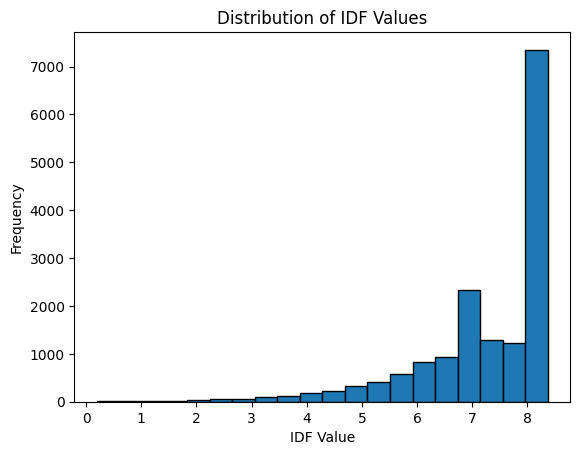

In [41]:
# plot distribution of IDF values
plt.hist(token_df['IDF'], bins=20, edgecolor='black')
plt.title("Distribution of IDF Values")
plt.xlabel("IDF Value")
plt.ylabel("Frequency")
plt.show()


In [42]:
# count the number of tokens with low IDF values (potential stop words)
low_idf_count = len(token_df[token_df['IDF'] < 2])
print(f"Number of tokens with IDF < 1 (potential stop words): {low_idf_count}")

Number of tokens with IDF < 1 (potential stop words): 58


In [43]:
token_df['Document_Frequency'].describe()

count    16075.000000
mean         0.003455
std          0.023704
min          0.000115
25%          0.000115
50%          0.000346
75%          0.001039
max          0.822179
Name: Document_Frequency, dtype: float64

In [44]:
# get the top 20 tokens with the highest document frequency
top_20_doc_freq = token_df.sort_values(by='Document_Frequency', ascending=False).head(20)
print("Top 20 tokens with highest document frequency:")
print(top_20_doc_freq[['Token', 'Document_Frequency']])

Top 20 tokens with highest document frequency:
    Token  Document_Frequency
36     37            0.822179
18     21            0.819409
13     16            0.800138
22     24            0.735749
69     67            0.649088
16     19            0.569467
1       4            0.552504
9      12            0.540734
32     33            0.511539
163   157            0.486730
284   264            0.455689
56     56            0.450496
8      11            0.450381
15     18            0.444727
55     55            0.440111
93     91            0.437111
83     81            0.400762
61     61            0.374683
86     84            0.362797
143   139            0.346642


In [45]:
token_df['Term_Frequency'].describe()

count    16075.000000
mean         0.000062
std          0.000681
min          0.000002
25%          0.000002
50%          0.000005
75%          0.000014
max          0.040092
Name: Term_Frequency, dtype: float64

In [46]:
q = token_df["IDF"].quantile(0.0025)   # bottom 0.25% IDF
stop_words = token_df[token_df["IDF"] <= q]["Token"].tolist()
print("Stop words based on bottom 0.25% IDF values:")
print(stop_words)
print(f"Number of stop words based on bottom 0.25% IDF values: {len(stop_words)}")

Stop words based on bottom 0.25% IDF values:
['4', '9', '11', '12', '16', '18', '19', '21', '24', '25', '33', '37', '41', '44', '46', '55', '56', '61', '66', '67', '68', '72', '79', '81', '84', '91', '94', '105', '119', '120', '139', '157', '114', '186', '259', '264', '325', '533', '536', '570', '4395']
Number of stop words based on bottom 0.25% IDF values: 41


# DU3: Collocation Discovery

In [65]:
# Get bigram frequencies from the training corpus
from collections import Counter
bigram_counts = Counter()
for text in train_indexed['TextIndexed']:
    tokens = text.split()
    bigrams = zip(tokens, tokens[1:])  # create bigrams by zipping the token list with itself offset by one
    bigram_counts.update(bigrams)
# convert bigram counts to a dataframe
bigram_df = pd.DataFrame(bigram_counts.items(), columns=['Bigram', 'Frequency'])
# get the top 20 most frequent bigrams
top_20_bigrams = bigram_df.sort_values(by='Frequency', ascending=False).head(20)
print("Top 20 most frequent bigrams in the training corpus:")
print(top_20_bigrams)

Top 20 most frequent bigrams in the training corpus:
           Bigram  Frequency
934     (56, 157)       2812
262      (12, 37)       1888
116      (16, 81)       1847
605     (264, 37)       1450
4401      (16, 9)       1279
56       (16, 41)       1232
257     (55, 157)       1194
979      (21, 16)       1190
281      (18, 33)       1167
282      (33, 24)       1128
140      (91, 33)       1127
2308    (105, 94)       1084
319     (186, 37)       1049
29        (4, 24)        997
34605  (55, 4395)        992
589     (16, 293)        974
397      (21, 37)        972
26       (24, 25)        958
207      (21, 56)        926
137      (19, 36)        920


In [ ]:
# Get the bigram frequencies
from collections import defaultdict
bigram_freq = defaultdict(int)
for text in train_indexed['TextIndexed']:
    tokens = text.split()
    for i in range(len(tokens) - 1):
        bigram = (tokens[i], tokens[i + 1])
        bigram_freq[bigram] += 1
# Convert bigram frequencies to a DataFrame for analysis
bigram_df = pd.DataFrame(bigram_freq.items(), columns=['Bigram', 'Frequency'])
print("Total number of unique bigrams:", len(bigram_df))
bigram_df.sort_values(by='Frequency', ascending=False, inplace=True)
print("Top 20 most frequent bigrams:")
print(bigram_df.head(20))

Total number of unique bigrams: 104091
Top 20 most frequent bigrams:
           Bigram  Frequency
934     (56, 157)       2812
262      (12, 37)       1888
116      (16, 81)       1847
605     (264, 37)       1450
4401      (16, 9)       1279
56       (16, 41)       1232
257     (55, 157)       1194
979      (21, 16)       1190
281      (18, 33)       1167
282      (33, 24)       1128
140      (91, 33)       1127
2308    (105, 94)       1084
319     (186, 37)       1049
29        (4, 24)        997
34605  (55, 4395)        992
589     (16, 293)        974
397      (21, 37)        972
26       (24, 25)        958
207      (21, 56)        926
137      (19, 36)        920


In [57]:
# filter out bigrams that appear less than 5 times in the training corpus
_low_frequency_bigrams = bigram_df[bigram_df['Frequency'] <= 5]['Bigram'].tolist()
print(f"Number of bigrams that appear less than 5 times: {len(_low_frequency_bigrams)}")

Number of bigrams that appear less than 5 times: 77597


In [58]:
filtered_bigram_df = bigram_df[bigram_df['Frequency'] >= 5]
print(f"Number of bigrams that appear 5 or more times: {len(filtered_bigram_df)}")

Number of bigrams that appear 5 or more times: 29090


In [59]:
# calculate observed mean for each bigram
filtered_bigram_df['Observed_Mean'] = filtered_bigram_df['Frequency'] / len(train_indexed)
filtered_bigram_df.head()


/var/folders/2c/b62fj2_s0yz81crbgdm7jg8w0000gn/T/ipykernel_25154/1646743331.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_bigram_df['Observed_Mean'] = filtered_bigram_df['Frequency'] / len(train_indexed)


,Bigram,Frequency,Observed_Mean
934,"(56, 157)",2812,0.324486
262,"(12, 37)",1888,0.217863
116,"(16, 81)",1847,0.213132
605,"(264, 37)",1450,0.167321
4401,"(16, 9)",1279,0.147588


In [ ]:
# calculate the expected mean for each bigram under the assumption of independence
# expected mean = (frequency of first token / total tokens) * (frequency of second token / total tokens)

# get token frequencies as a dictionary for quick lookup
token_freq_dict = dict(zip(token_df['Token'], token_df['Frequency']))
total_tokens = sum(token_df['Frequency'])

def calculate_expected_mean(bigram: tuple) -> float:
    token1, token2 = bigram
    freq_token1 = token_freq_dict.get(token1, 0)
    freq_token2 = token_freq_dict.get(token2, 0)
    expected_mean = (freq_token1 / total_tokens) * (freq_token2 / total_tokens)
    return expected_mean    

# calculate expected mean for each bigram and add it to the dataframe
for index, row in filtered_bigram_df.iterrows():
    bigram = row['Bigram']
    expected_mean = calculate_expected_mean(bigram)
    filtered_bigram_df.at[index, 'Expected_Mean'] = expected_mean

filtered_bigram_df.head()

,Bigram,Frequency,Observed_Mean,Expected_Mean,T_Test_Statistic
934,"(56, 157)",2812,0.324486,0.000137,64.492228
262,"(12, 37)",1888,0.217863,0.000630,48.989306
116,"(16, 81)",1847,0.213132,0.000269,48.387690
605,"(264, 37)",1450,0.167321,0.000405,41.628723
4401,"(16, 9)",1279,0.147588,0.000179,38.688748


In [61]:
# calculate the t-test statistic for each bigram to identify collocations
filtered_bigram_df['T_Test_Statistic'] = (filtered_bigram_df['Observed_Mean'] - filtered_bigram_df['Expected_Mean']) / (filtered_bigram_df['Observed_Mean'] * (1 - filtered_bigram_df['Observed_Mean']) / len(train_indexed))**0.5
filtered_bigram_df.head(20)

/var/folders/2c/b62fj2_s0yz81crbgdm7jg8w0000gn/T/ipykernel_25154/266067251.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_bigram_df['T_Test_Statistic'] = (filtered_bigram_df['Observed_Mean'] - filtered_bigram_df['Expected_Mean']) / (filtered_bigram_df['Observed_Mean'] * (1 - filtered_bigram_df['Observed_Mean']) / len(train_indexed))**0.5


,Bigram,Frequency,Observed_Mean,Expected_Mean,T_Test_Statistic
934,"(56, 157)",2812,0.324486,0.000137,64.492228
262,"(12, 37)",1888,0.217863,0.000630,48.989306
116,"(16, 81)",1847,0.213132,0.000269,48.387690
605,"(264, 37)",1450,0.167321,0.000405,41.628723
4401,"(16, 9)",1279,0.147588,0.000179,38.688748
56,"(16, 41)",1232,0.142165,0.000193,37.845319
257,"(55, 157)",1194,0.137780,0.000115,37.181917
979,"(21, 16)",1190,0.137318,0.000992,36.872195
281,"(18, 33)",1167,0.134664,0.000126,36.689057
282,"(33, 24)",1128,0.130164,0.000328,35.920288


In [62]:
# filter out bigrams that fail to meet a significance threshold (e.g., t-test statistic > 2.576)
significant_bigrams = filtered_bigram_df[filtered_bigram_df['T_Test_Statistic'] > 2.576]
print(f"Number of significant bigrams (t-test statistic > 2.576): {len(significant_bigrams)}")
print("Top 20 significant bigrams:")
print(significant_bigrams.sort_values(by='T_Test_Statistic', ascending=False).head(20)[['Bigram', 'T_Test_Statistic']])

Number of significant bigrams (t-test statistic > 2.576): 23075
Top 20 significant bigrams:
           Bigram  T_Test_Statistic
934     (56, 157)         64.492228
262      (12, 37)         48.989306
116      (16, 81)         48.387690
605     (264, 37)         41.628723
4401      (16, 9)         38.688748
56       (16, 41)         37.845319
257     (55, 157)         37.181917
979      (21, 16)         36.872195
281      (18, 33)         36.689057
140      (91, 33)         35.944796
282      (33, 24)         35.920288
2308    (105, 94)         35.192505
319     (186, 37)         34.477720
29        (4, 24)         33.467622
34605  (55, 4395)         33.452663
589     (16, 293)         33.109686
26       (24, 25)         32.777612
397      (21, 37)         32.740537
207      (21, 56)         32.100600
137      (19, 36)         32.069770


## A1 Natural Language Modelling

### MLE

In [ ]:
class MaximumLikelihoodEstimation:
    